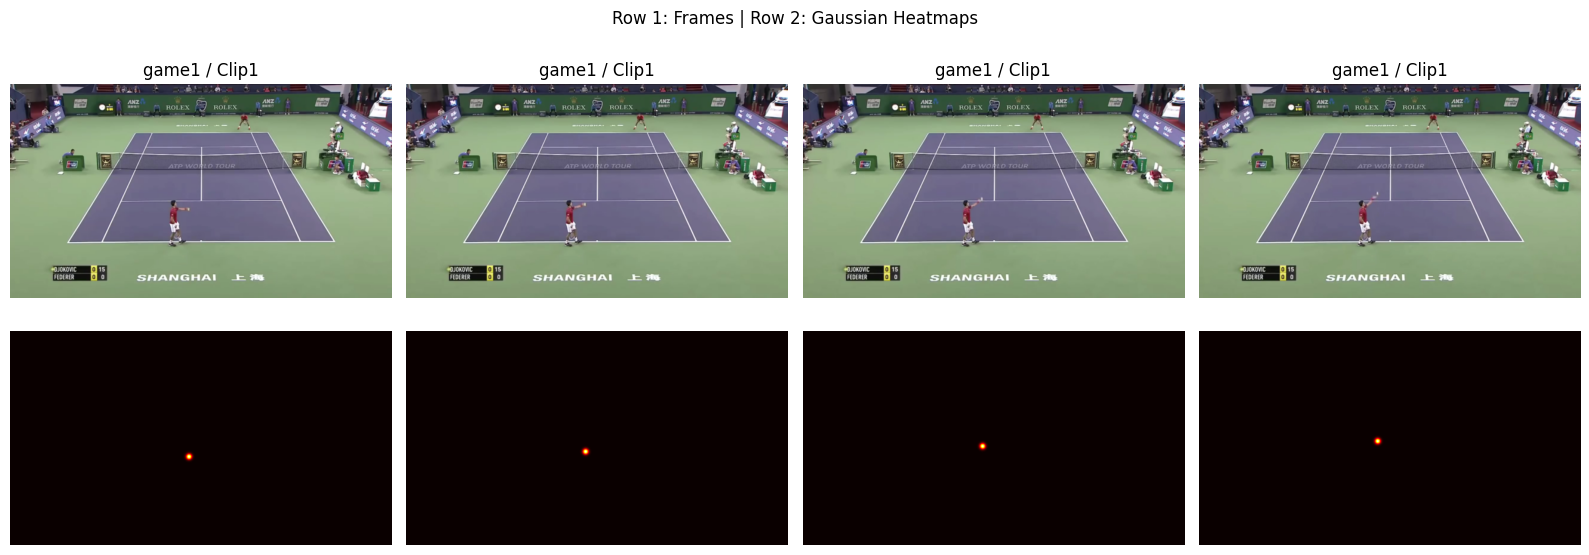

Dataset size: 19835
Image shape: torch.Size([4, 3, 360, 640])
Heatmap shape: torch.Size([4, 1, 360, 640])


In [ ]:
# Chat generated test
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from dataloader import BallDataset

# Init dataset
game_list = [f"game{i}" for i in range(1, 11)]
dataset = BallDataset(game_list)

loader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=2)

# Get one batch
imgs, heatmaps, games, clips = next(iter(loader))

# Show images + heatmaps
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i in range(4):
    # Image (denormalize from [-1,1] → [0,1])
    img = imgs[i].permute(1, 2, 0) * 0.5 + 0.5
    axes[0, i].imshow(img.numpy())
    axes[0, i].set_title(f"{games[i]} / {clips[i]}")
    axes[0, i].axis("off")

    # Heatmap
    axes[1, i].imshow(heatmaps[i].squeeze(0).numpy(), cmap="hot")
    axes[1, i].axis("off")

plt.suptitle("Row 1: Frames | Row 2: Gaussian Heatmaps")
plt.tight_layout()
plt.show()

print(f"Dataset size: {len(dataset)}")
print(f"Image shape: {imgs.shape}")    # (4, 3, H, W)
print(f"Heatmap shape: {heatmaps.shape}")  # (4, 1, H, W)